In [73]:
import os
import argparse
# import plumbum
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from pandas.tseries.offsets import CustomBusinessDay
from pandas.tseries.holiday import USFederalHolidayCalendar

from tqdm import tqdm
from pathlib import Path
from loguru import logger
from beartype import beartype
from datetime import timedelta
from typing import Union, Literal

path = Path.cwd().parent / "datasets" / "excel"
os.path.exists(path), path


(True, PosixPath('/Users/mac/Downloads/Group_1/datasets/excel'))

In [ ]:
tickers = pd.read_excel(path / "tickers.xlsx", index_col=0)
tickers = tickers.iloc[:, 0].tolist()

df_stats = pd.read_excel(path / "etf_nasdaq.xlsx", sheet_name=tickers)
df_stats


{'AAPU':            Date  OpenPrice  LastPrice  MinPrice  MaxPrice        Volume  \
 0    2016-01-04        NaN        NaN       NaN       NaN           NaN   
 1    2016-01-05        NaN        NaN       NaN       NaN           NaN   
 2    2016-01-06        NaN        NaN       NaN       NaN           NaN   
 3    2016-01-07        NaN        NaN       NaN       NaN           NaN   
 4    2016-01-08        NaN        NaN       NaN       NaN           NaN   
 ...         ...        ...        ...       ...       ...           ...   
 2499 2025-12-24      39.52    39.4650   39.4650     39.52  3.090014e+04   
 2500 2025-12-26      39.48    39.4231   39.3750     39.48  3.230361e+05   
 2501 2025-12-29      39.39    39.3703   39.3703     39.39  1.684637e+05   
 2502 2025-12-30      39.38    39.3517   39.3517     39.42  2.714249e+06   
 2503 2025-12-31      39.23    39.0683   39.0100     39.23  5.693200e+05   
 
         AUM (USD)  DistrAmount  PayableDate  MidPrice    Spread   AskPrice  \

In [ ]:
summmary = pd.read_excel(path.parent / "csv" / "summary.xlsx", index_col=0)
summmary


In [44]:
first_business_days = pd.read_excel(path / "business_dates.xlsx", index_col=0)
first_business_days = first_business_days['Values'].iloc[1:]
first_business_days


1     2016-02-01
2     2016-03-01
3     2016-04-01
4     2016-05-02
5     2016-06-01
         ...    
115   2025-08-01
116   2025-09-02
117   2025-10-01
118   2025-11-03
119   2025-12-01
Name: Values, Length: 119, dtype: datetime64[ns]

In [18]:
sheet_names_str = [key.strftime('%Y-%m-%d') for key in first_business_days]
# portfolios_rebalance = pd.read_excel(path / "portfolio_rebalance.xlsx", sheet_name=sheet_names_str)
portfolios = pd.read_excel(path / "portfolio_rebalance.xlsx", sheet_name=sheet_names_str)
portfolios


{'2016-02-01':     Key  Value
 0   BIL      1
 1  SPTI      1,
 '2016-03-01':     Key  Value
 0   BIL      1
 1  SPSB      1
 2  SPTI      1,
 '2016-04-01':     Key  Value
 0   BIL      1
 1   SHE      1
 2   SHM      1
 3  SPSB      1,
 '2016-05-02':     Key  Value
 0   BIL      1
 1   SHM      1
 2  SPAB      1
 3  SPSB      1
 4  SPTI      1,
 '2016-06-01':     Key  Value
 0   BIL      1
 1   SHM      1
 2  SPSB      1,
 '2016-07-01':     Key  Value
 0   BIL      1
 1   CWI      1
 2   DWX      1
 3   RWX      1
 4   SHM      1
 5  SPSB      1
 6  TOTL      1,
 '2016-08-01':     Key  Value
 0   BIL      1
 1   CWI      1
 2   DWX      1
 3   RWX      1
 4   SHM      1
 5  SPSB      1
 6  TOTL      1,
 '2016-09-01':     Key  Value
 0   BIL      1
 1   CWI      1
 2   SHM      1
 3  SPSB      1,
 '2016-10-03':     Key  Value
 0   BIL      1
 1   CWI      1
 2   SHM      1
 3  SPSB      1,
 '2016-11-01':     Key  Value
 0   BIL      1
 1   RWX      1
 2   SHM      1
 3  SPSB      1
 4 

In [19]:
returns_all = pd.read_excel(path / "etf_returns.xlsx")
ewma_returns_all = pd.read_excel(path / "etf_ewma.xlsx")
ewma_returns_all


,Date,AAA,AAAU,AADR,AAUS,AAVM,AAXJ,ABCS,ABEQ,ABI,...,ZIPP,ZROZ,ZSB,ZSC,ZSPY,ZTAX,ZTEN,ZTOP,ZTRE,ZTWO
0,2016-01-04,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
1,2016-01-05,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000975,0.000000,0.000000,0.000000,...,0.000000,-0.004130,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
2,2016-01-06,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-0.006054,0.000000,0.000000,0.000000,...,0.000000,0.004214,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
3,2016-01-07,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-0.011802,0.000000,0.000000,0.000000,...,0.000000,0.003238,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
4,2016-01-08,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-0.011072,0.000000,0.000000,0.000000,...,0.000000,0.003666,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2499,2025-12-24,0.000006,-5.852057e-13,0.000908,0.000776,0.001315,0.000490,0.000693,0.000657,-0.000211,...,0.000172,-0.000254,0.004104,0.001442,-2.062263e-09,0.000026,0.000153,0.000030,0.000049,4.306358e-05
2500,2025-12-26,-0.000048,-5.718396e-13,0.001016,0.000748,0.001267,0.000670,0.000700,0.000622,-0.000182,...,0.000264,-0.000400,0.004375,0.001419,-2.015160e-09,0.000472,0.000165,0.000017,0.000070,6.008951e-05
2501,2025-12-29,-0.000021,-5.587788e-13,0.000656,0.000626,0.001092,0.000616,0.000599,0.000452,-0.000166,...,0.000355,-0.000308,0.003852,0.001549,-1.969134e-09,0.000611,0.000186,0.000042,0.000081,7.446009e-05
2502,2025-12-30,-0.000011,-5.460163e-13,0.000689,0.000585,0.000637,0.000683,0.000577,0.000322,-0.000145,...,0.000406,-0.000401,0.004099,0.001412,-1.924159e-09,-0.000121,0.000068,-0.000011,0.000008,6.758257e-07


In [20]:
returns_rebalance = pd.read_excel(path / "returns_rebalance.xlsx", sheet_name=sheet_names_str)
cov_returns_rebalance = pd.read_excel(path / "ewma_cov_returns_rebalance.xlsx", sheet_name=sheet_names_str)
cov_returns_rebalance


{'2016-02-01':             BIL          SPTI
 0  1.239921e-09 -4.209922e-09
 1 -4.209922e-09  7.812484e-08,
 '2016-03-01':             BIL          SPSB          SPTI
 0  6.672807e-11  2.612616e-10 -1.073370e-10
 1  2.612616e-10  4.929169e-09 -4.086850e-09
 2 -1.073370e-10 -4.086850e-09  2.136344e-08,
 '2016-04-01':             BIL           SHE           SHM          SPSB
 0  1.275891e-11 -2.277134e-09  2.966463e-11  3.922835e-11
 1 -2.277134e-09  2.507284e-06 -1.860711e-08  6.768048e-08
 2  2.966463e-11 -1.860711e-08  1.300218e-09 -1.529383e-10
 3  3.922835e-11  6.768048e-08 -1.529383e-10  6.271090e-09,
 '2016-05-02':             BIL           SHM          SPAB          SPSB          SPTI
 0  1.063782e-11  1.328732e-11  3.828011e-12 -1.918477e-11 -9.901995e-12
 1  1.328732e-11  8.848778e-10 -3.277851e-10 -1.076120e-10 -6.310626e-10
 2  3.828011e-12 -3.277851e-10  7.748667e-09  1.003475e-09  7.315980e-09
 3 -1.918477e-11 -1.076120e-10  1.003475e-09  3.940698e-10  1.011171e-09
 4 -9.90

In [45]:
sheet_names_str = [key.strftime('%Y-%m-%d') for key in first_business_days]
weights_rebalance = pd.read_excel(path / "weights_rebalance.xlsx", sheet_name=sheet_names_str)
weights_rebalance


{'2016-02-01':        Key  Value
 0      AAA      0
 1     AAAU      0
 2     AADR      0
 3     AAUS      0
 4     AAVM      0
 ...    ...    ...
 3549  ZTAX      0
 3550  ZTEN      0
 3551  ZTOP      0
 3552  ZTRE      0
 3553  ZTWO      0
 
 [3554 rows x 2 columns],
 '2016-03-01':        Key  Value
 0      AAA      0
 1     AAAU      0
 2     AADR      0
 3     AAUS      0
 4     AAVM      0
 ...    ...    ...
 3549  ZTAX      0
 3550  ZTEN      0
 3551  ZTOP      0
 3552  ZTRE      0
 3553  ZTWO      0
 
 [3554 rows x 2 columns],
 '2016-04-01':        Key  Value
 0      AAA      0
 1     AAAU      0
 2     AADR      0
 3     AAUS      0
 4     AAVM      0
 ...    ...    ...
 3549  ZTAX      0
 3550  ZTEN      0
 3551  ZTOP      0
 3552  ZTRE      0
 3553  ZTWO      0
 
 [3554 rows x 2 columns],
 '2016-05-02':        Key  Value
 0      AAA      0
 1     AAAU      0
 2     AADR      0
 3     AAUS      0
 4     AAVM      0
 ...    ...    ...
 3549  ZTAX      0
 3550  ZTEN      0
 3551

In [58]:
indexes = []
for ind, date in enumerate(first_business_days):
    if 'weights' in weights_rebalance[date.strftime("%Y-%m-%d")].columns:
        indexes.append(ind)

indexes


[35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117]

In [80]:
index = indexes[3]
weights_dates = list(weights_rebalance.keys())
mask = weights_rebalance[weights_dates[index]]['weights'].apply(lambda x: x > 0)
weights_rebalance[weights_dates[index]][mask]


,Key,Value,weights
230,BIL,1,0.158344
787,EBND,1,0.000235
1133,FLRN,1,0.158310
1400,GXC,1,0.000263
1500,HYMB,1,0.000226
2802,SHM,1,0.158334
2833,SJNK,1,0.000230
2883,SPAB,1,0.000233
2909,SPIB,1,0.016083
2910,SPIP,1,0.016053


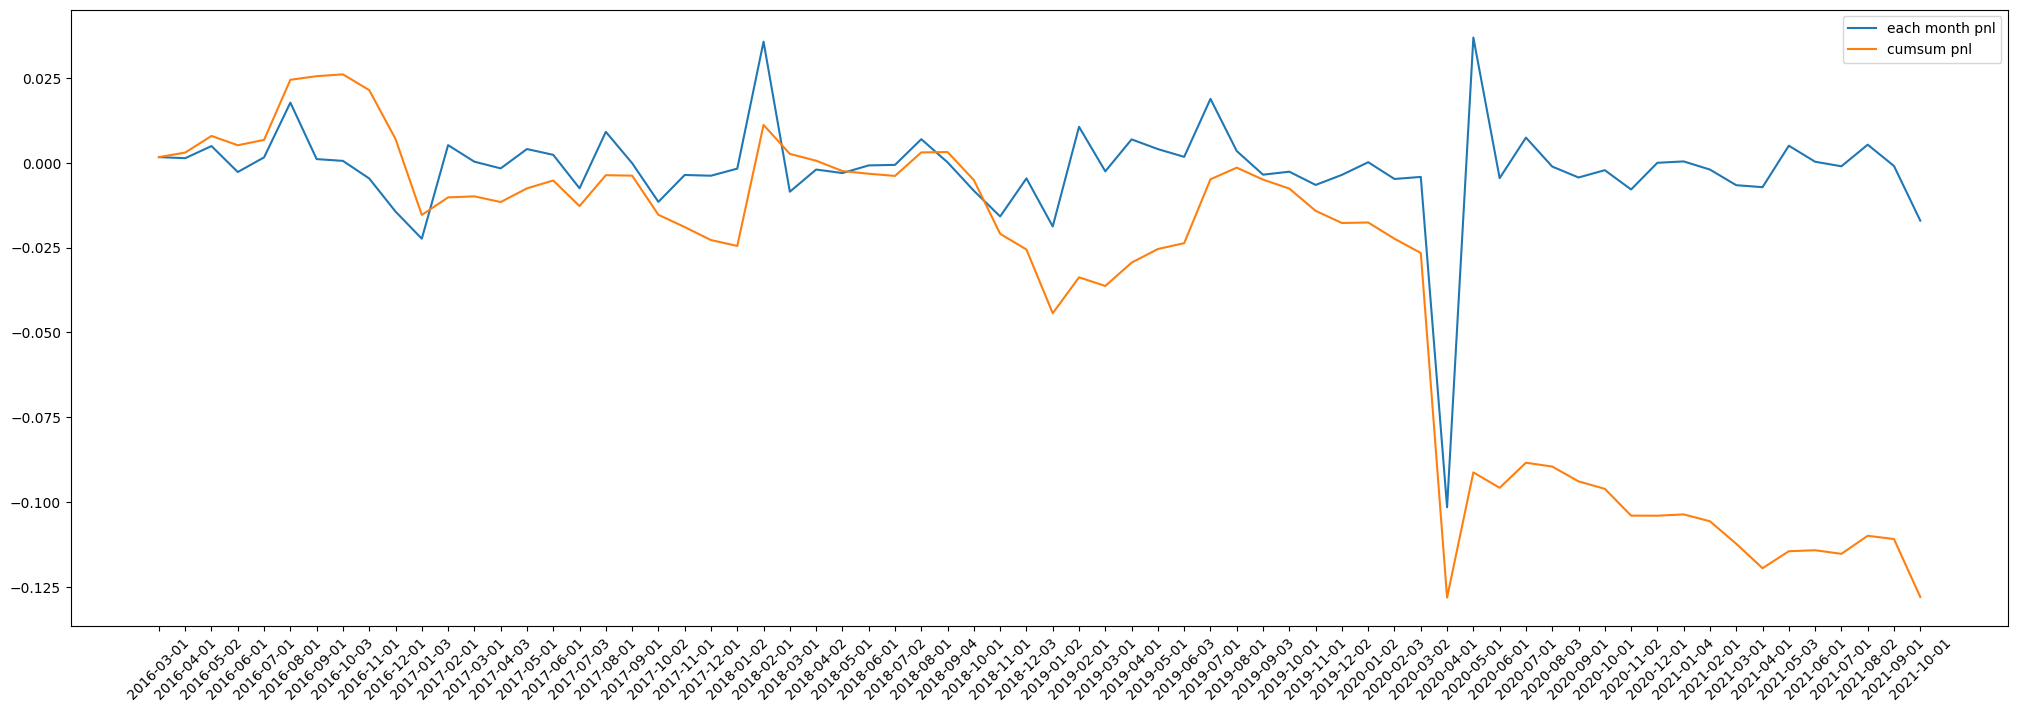

In [30]:
pnls = pd.read_csv(path / "pnl.csv")
plt.figure(figsize=(25,8))
plt.plot(pnls['Date'], pnls['PnL'], label='each month pnl')
plt.plot(pnls['Date'], pnls['PnL'].cumsum(), label='cumsum pnl')
plt.legend(), plt.xticks(rotation=45)
plt.show()


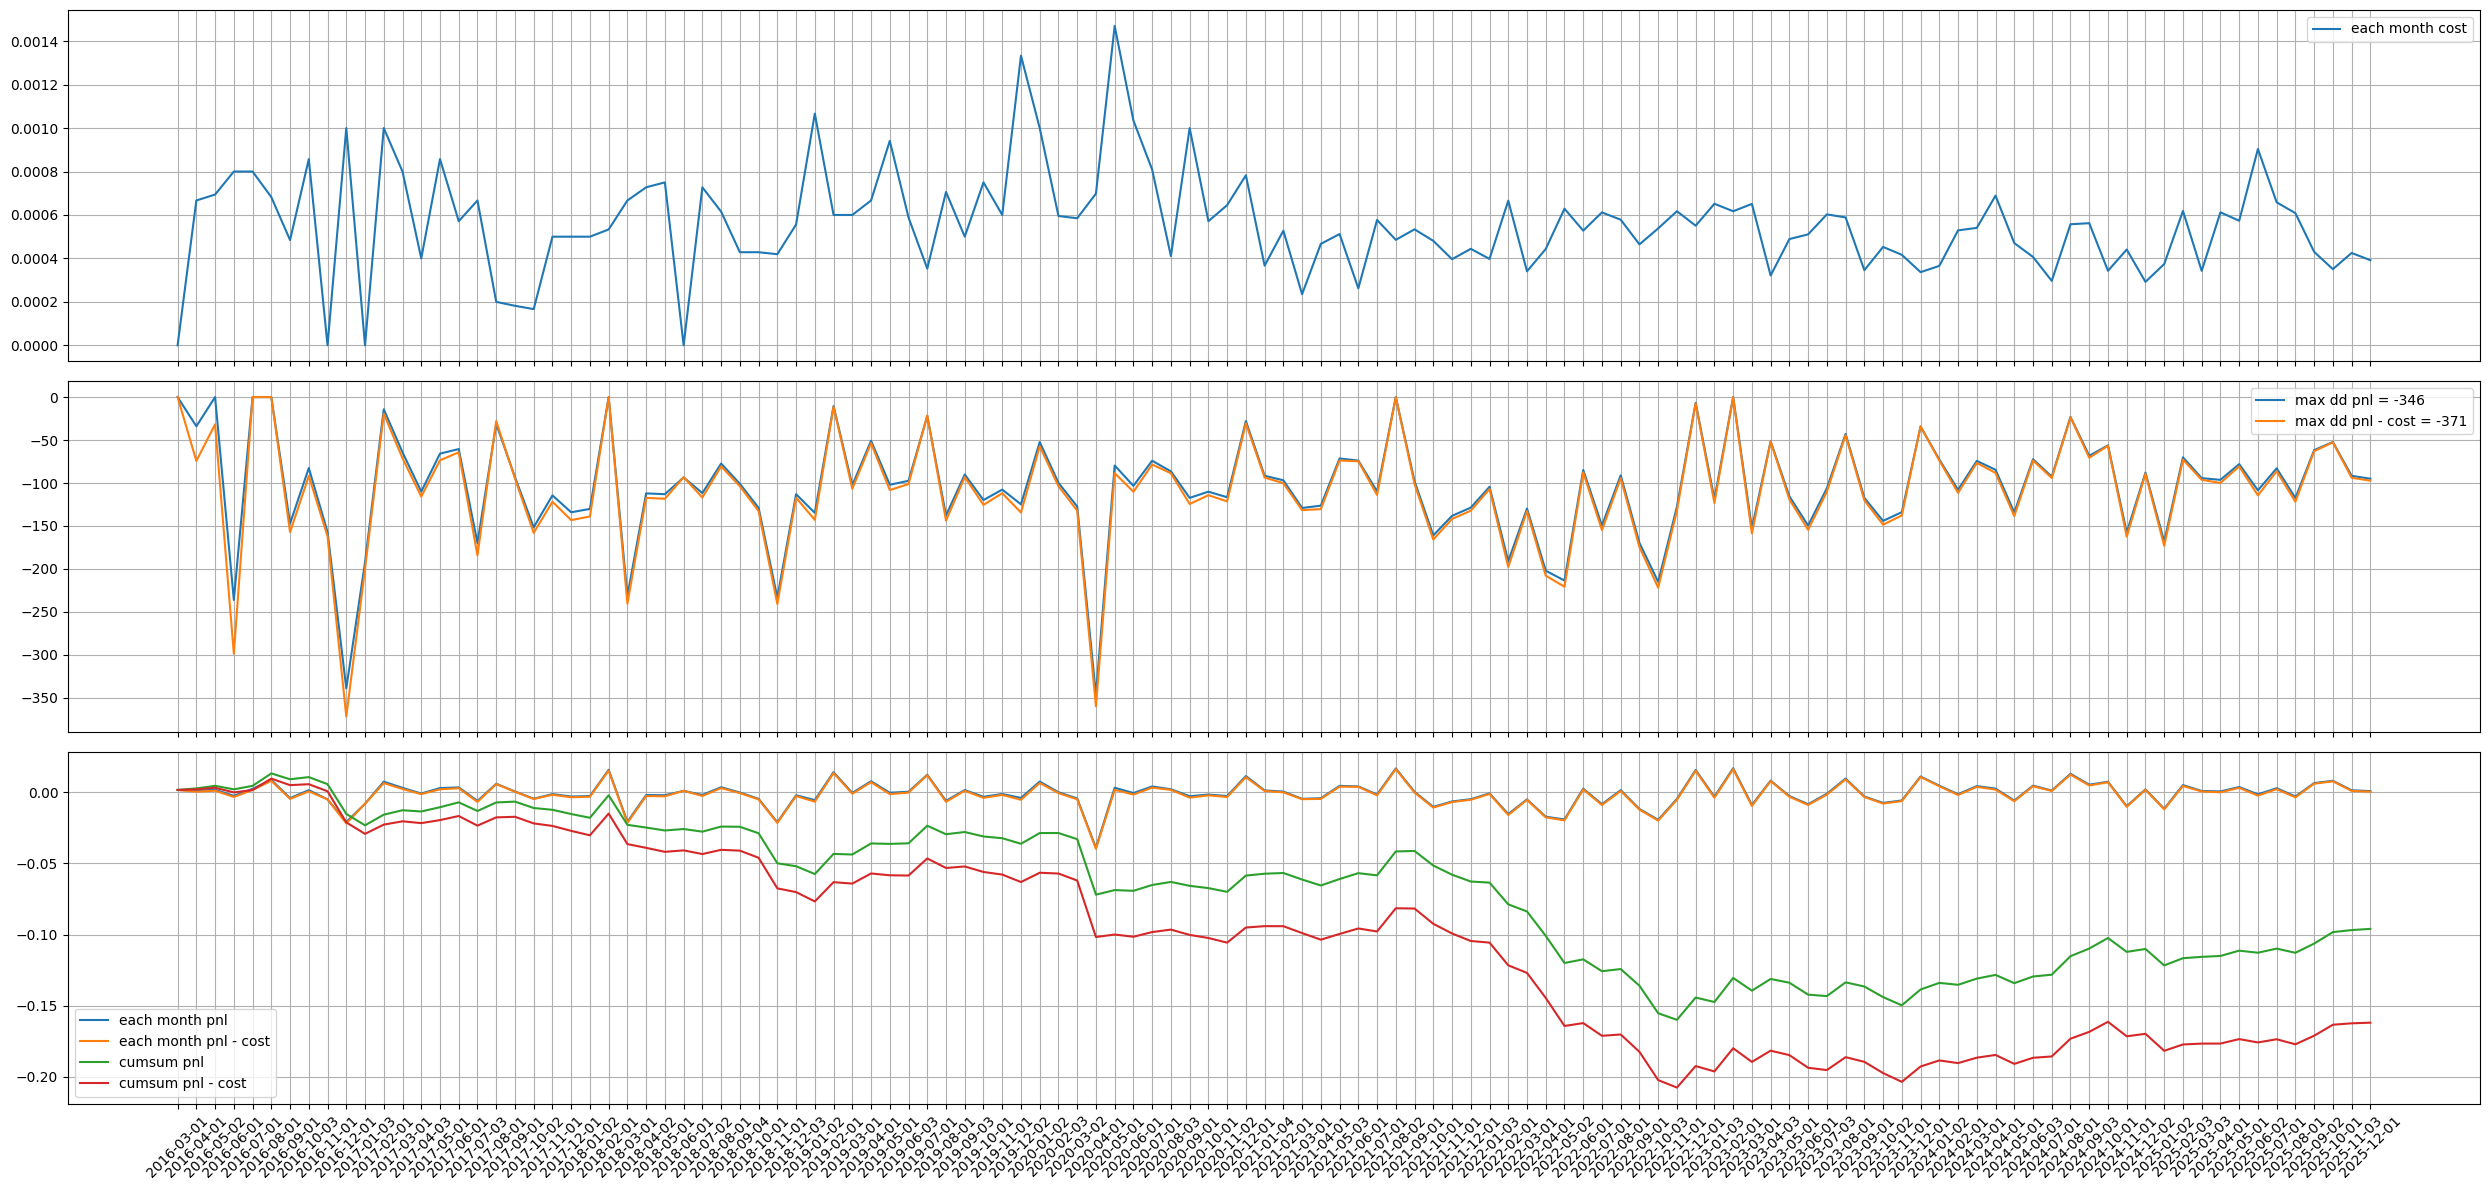

(([0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,
   95,
   96,
   97,
   98,
   99,
   100,
   101,
   102,
   103,
   104,
   105,
   106,
   107,
   108,
   109,
   110,
   111,
   112,
   113,
   114,
   115,
   116,
   117],
  [Text(0, 0, '2016-03-01'),
   Text(1, 0, '2016-04-01'),
   Text(2, 0, '2016-05-02'),
   Text(3, 0, '2016-06-01'),
   Text(4, 0, '2016-07-01'),
   Text(5, 0, '2016-

In [ ]:
# turnover_penalty = 0.001
pnls = pd.read_csv(path / "pnl.csv")
fig, axes = plt.subplots(3, 1, figsize=(25,12), sharex=True)

axes[0].plot(pnls['Date'], pnls['Cost'], label='each month cost')
# axes[0].plot(pnls['Date'], pnls['Cost'].cumsum(), label='cumsum cost')

running_peak = np.maximum.accumulate(pnls['PnL'])
max_drawdown = (pnls['PnL'] - running_peak) / running_peak * 100
axes[1].plot(pnls['Date'], max_drawdown, label=f'max dd pnl = {int(max_drawdown.min())}')

running_peak = np.maximum.accumulate(pnls['PnL'] - pnls['Cost'])
max_drawdown = (pnls['PnL'] - pnls['Cost'] - running_peak) / running_peak * 100
axes[1].plot(pnls['Date'], max_drawdown, label=f'max dd pnl - cost = {int(max_drawdown.min())}')

axes[2].plot(pnls['Date'], pnls['PnL'], label='each month pnl')
axes[2].plot(pnls['Date'], pnls['PnL']-pnls['Cost'], label='each month pnl - cost')
axes[2].plot(pnls['Date'], pnls['PnL'].cumsum(), label='cumsum pnl')
axes[2].plot(pnls['Date'], (pnls['PnL']-pnls['Cost']).cumsum(), label='cumsum pnl - cost')

for i in range(3):
    axes[i].legend(), axes[i].grid()
    

plt.xticks(rotation=45), plt.tight_layout(), plt.show()


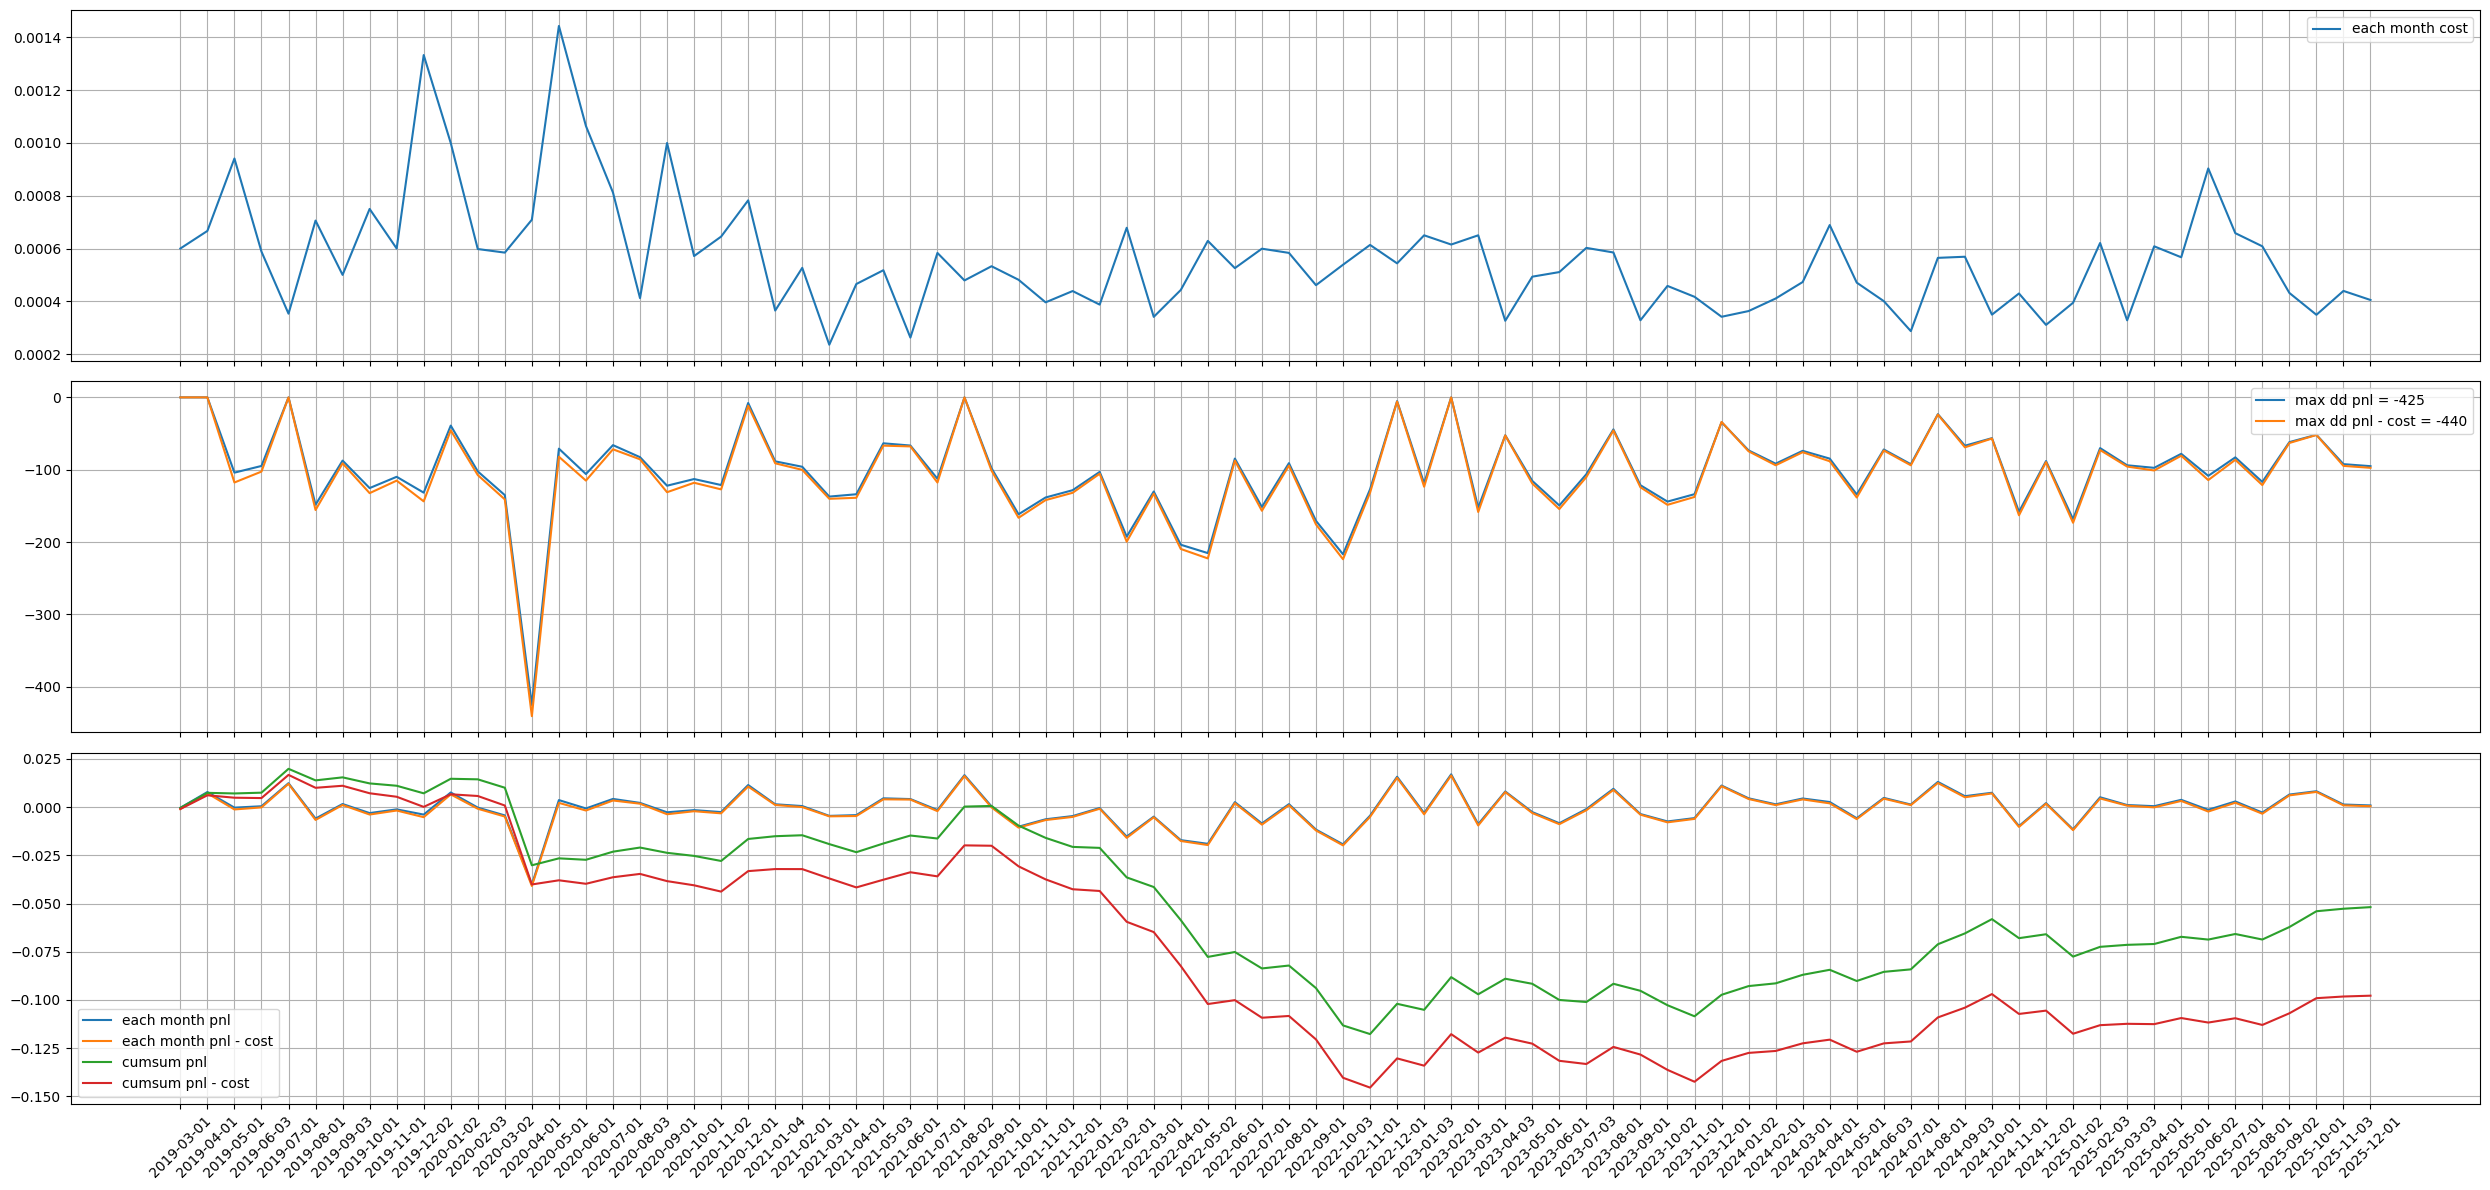

(([0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81],
  [Text(0, 0, '2019-03-01'),
   Text(1, 0, '2019-04-01'),
   Text(2, 0, '2019-05-01'),
   Text(3, 0, '2019-06-03'),
   Text(4, 0, '2019-07-01'),
   Text(5, 0, '2019-08-01'),
   Text(6, 0, '2019-09-03'),
   Text(7, 0, '2019-10-01'),
   Text(8, 0, '2019-11-01'),
   Text(9, 0, '2019-12-02'),
   Text(10, 0, '2020-01-02'),
   Text(11, 0, '2020-02-03'),
   Text(12, 0, '2020-03-02'),
   Text(13, 0, '2020-04-01'),
   Text(14, 0, '2020-05-0

In [ ]:
# turnover_penalty = 0.001, max_iter=100
pnls = pd.read_csv(path / "pnl.csv")
fig, axes = plt.subplots(3, 1, figsize=(25,12), sharex=True)

axes[0].plot(pnls['Date'], pnls['Cost'], label='each month cost')
# axes[0].plot(pnls['Date'], pnls['Cost'].cumsum(), label='cumsum cost')

running_peak = np.maximum.accumulate(pnls['PnL'])
max_drawdown = (pnls['PnL'] - running_peak) / running_peak * 100
axes[1].plot(pnls['Date'], max_drawdown, label=f'max dd pnl = {int(max_drawdown.min())}')

running_peak = np.maximum.accumulate(pnls['PnL'] - pnls['Cost'])
max_drawdown = (pnls['PnL'] - pnls['Cost'] - running_peak) / running_peak * 100
axes[1].plot(pnls['Date'], max_drawdown, label=f'max dd pnl - cost = {int(max_drawdown.min())}')

axes[2].plot(pnls['Date'], pnls['PnL'], label='each month pnl')
axes[2].plot(pnls['Date'], pnls['PnL']-pnls['Cost'], label='each month pnl - cost')
axes[2].plot(pnls['Date'], pnls['PnL'].cumsum(), label='cumsum pnl')
axes[2].plot(pnls['Date'], (pnls['PnL']-pnls['Cost']).cumsum(), label='cumsum pnl - cost')

for i in range(3):
    axes[i].legend(), axes[i].grid()

plt.xticks(rotation=45), plt.tight_layout(), plt.show()


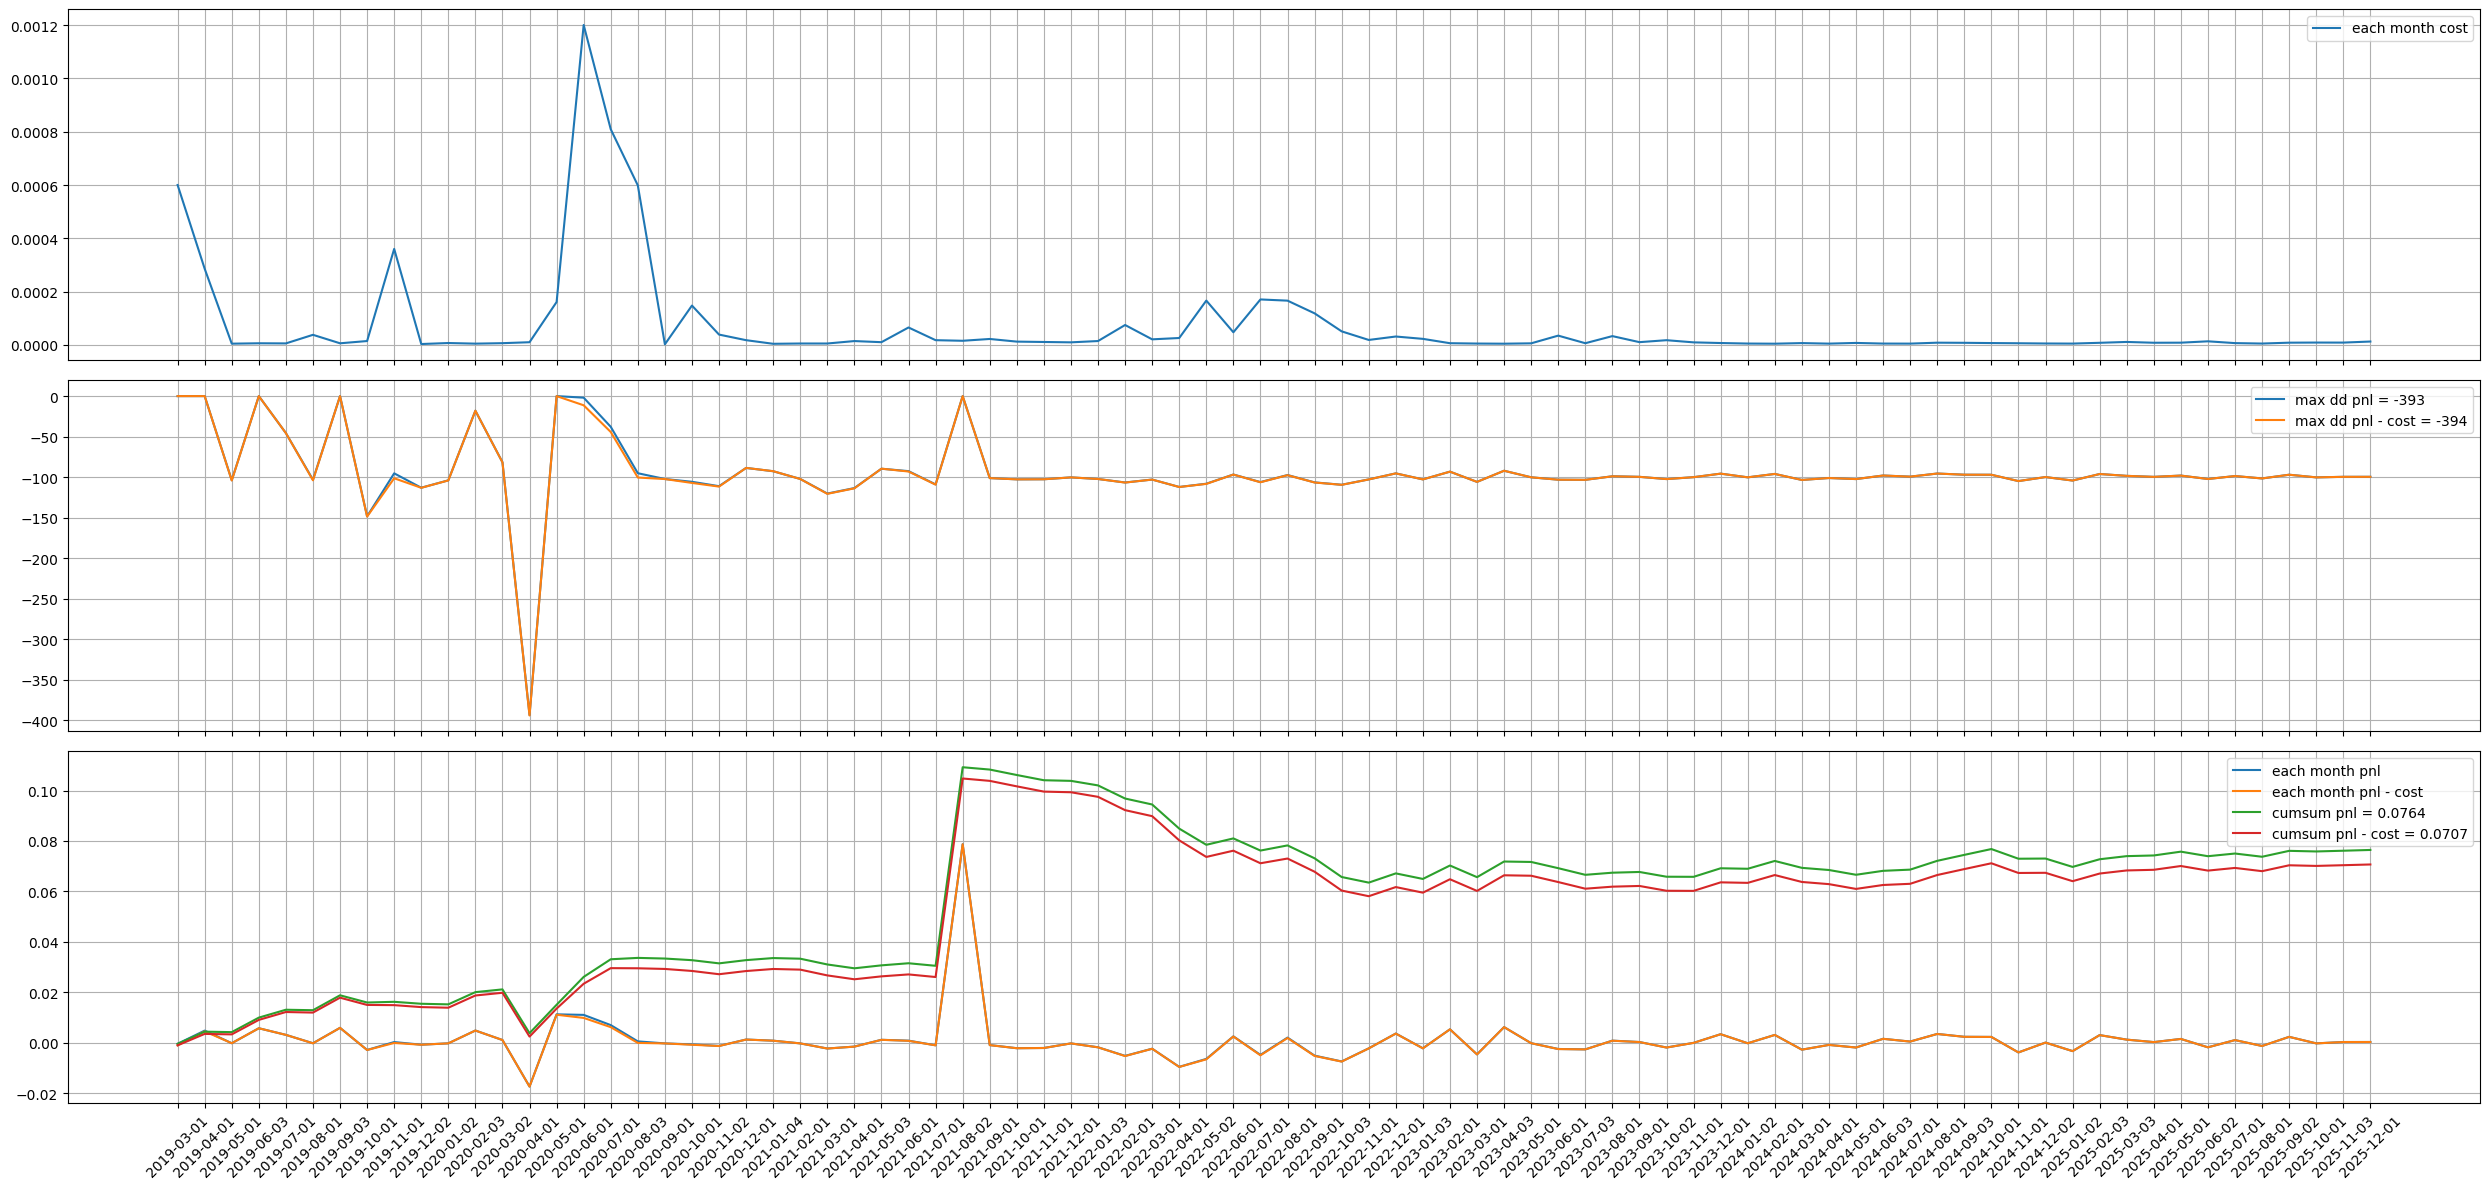

(([0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81],
  [Text(0, 0, '2019-03-01'),
   Text(1, 0, '2019-04-01'),
   Text(2, 0, '2019-05-01'),
   Text(3, 0, '2019-06-03'),
   Text(4, 0, '2019-07-01'),
   Text(5, 0, '2019-08-01'),
   Text(6, 0, '2019-09-03'),
   Text(7, 0, '2019-10-01'),
   Text(8, 0, '2019-11-01'),
   Text(9, 0, '2019-12-02'),
   Text(10, 0, '2020-01-02'),
   Text(11, 0, '2020-02-03'),
   Text(12, 0, '2020-03-02'),
   Text(13, 0, '2020-04-01'),
   Text(14, 0, '2020-05-0

In [72]:
# turnover_penalty = 1.0, max_iter=100 + max_iter=1000 + no limits in max_iter
pnls = pd.read_csv(path / "pnl.csv")
fig, axes = plt.subplots(3, 1, figsize=(25,12), sharex=True)

axes[0].plot(pnls['Date'], pnls['Cost'], label='each month cost')
# axes[0].plot(pnls['Date'], pnls['Cost'].cumsum(), label='cumsum cost')

running_peak = np.maximum.accumulate(pnls['PnL'])
max_drawdown = (pnls['PnL'] - running_peak) / running_peak * 100
axes[1].plot(pnls['Date'], max_drawdown, label=f'max dd pnl = {int(max_drawdown.min())}')

running_peak = np.maximum.accumulate(pnls['PnL'] - pnls['Cost'])
max_drawdown = (pnls['PnL'] - pnls['Cost'] - running_peak) / running_peak * 100
axes[1].plot(pnls['Date'], max_drawdown, label=f'max dd pnl - cost = {int(max_drawdown.min())}')

axes[2].plot(pnls['Date'], pnls['PnL'], label='each month pnl')
axes[2].plot(pnls['Date'], pnls['PnL']-pnls['Cost'], label='each month pnl - cost')
axes[2].plot(pnls['Date'], pnls['PnL'].cumsum(), label=f"cumsum pnl = {round(pnls['PnL'].cumsum().iloc[-1], 4)}")
axes[2].plot(pnls['Date'], (pnls['PnL']-pnls['Cost']).cumsum(), label=f"cumsum pnl - cost = {round((pnls['PnL']-pnls['Cost']).cumsum().iloc[-1], 4)}")

for i in range(3):
    axes[i].legend(), axes[i].grid()

plt.xticks(rotation=45), plt.tight_layout(), plt.show()


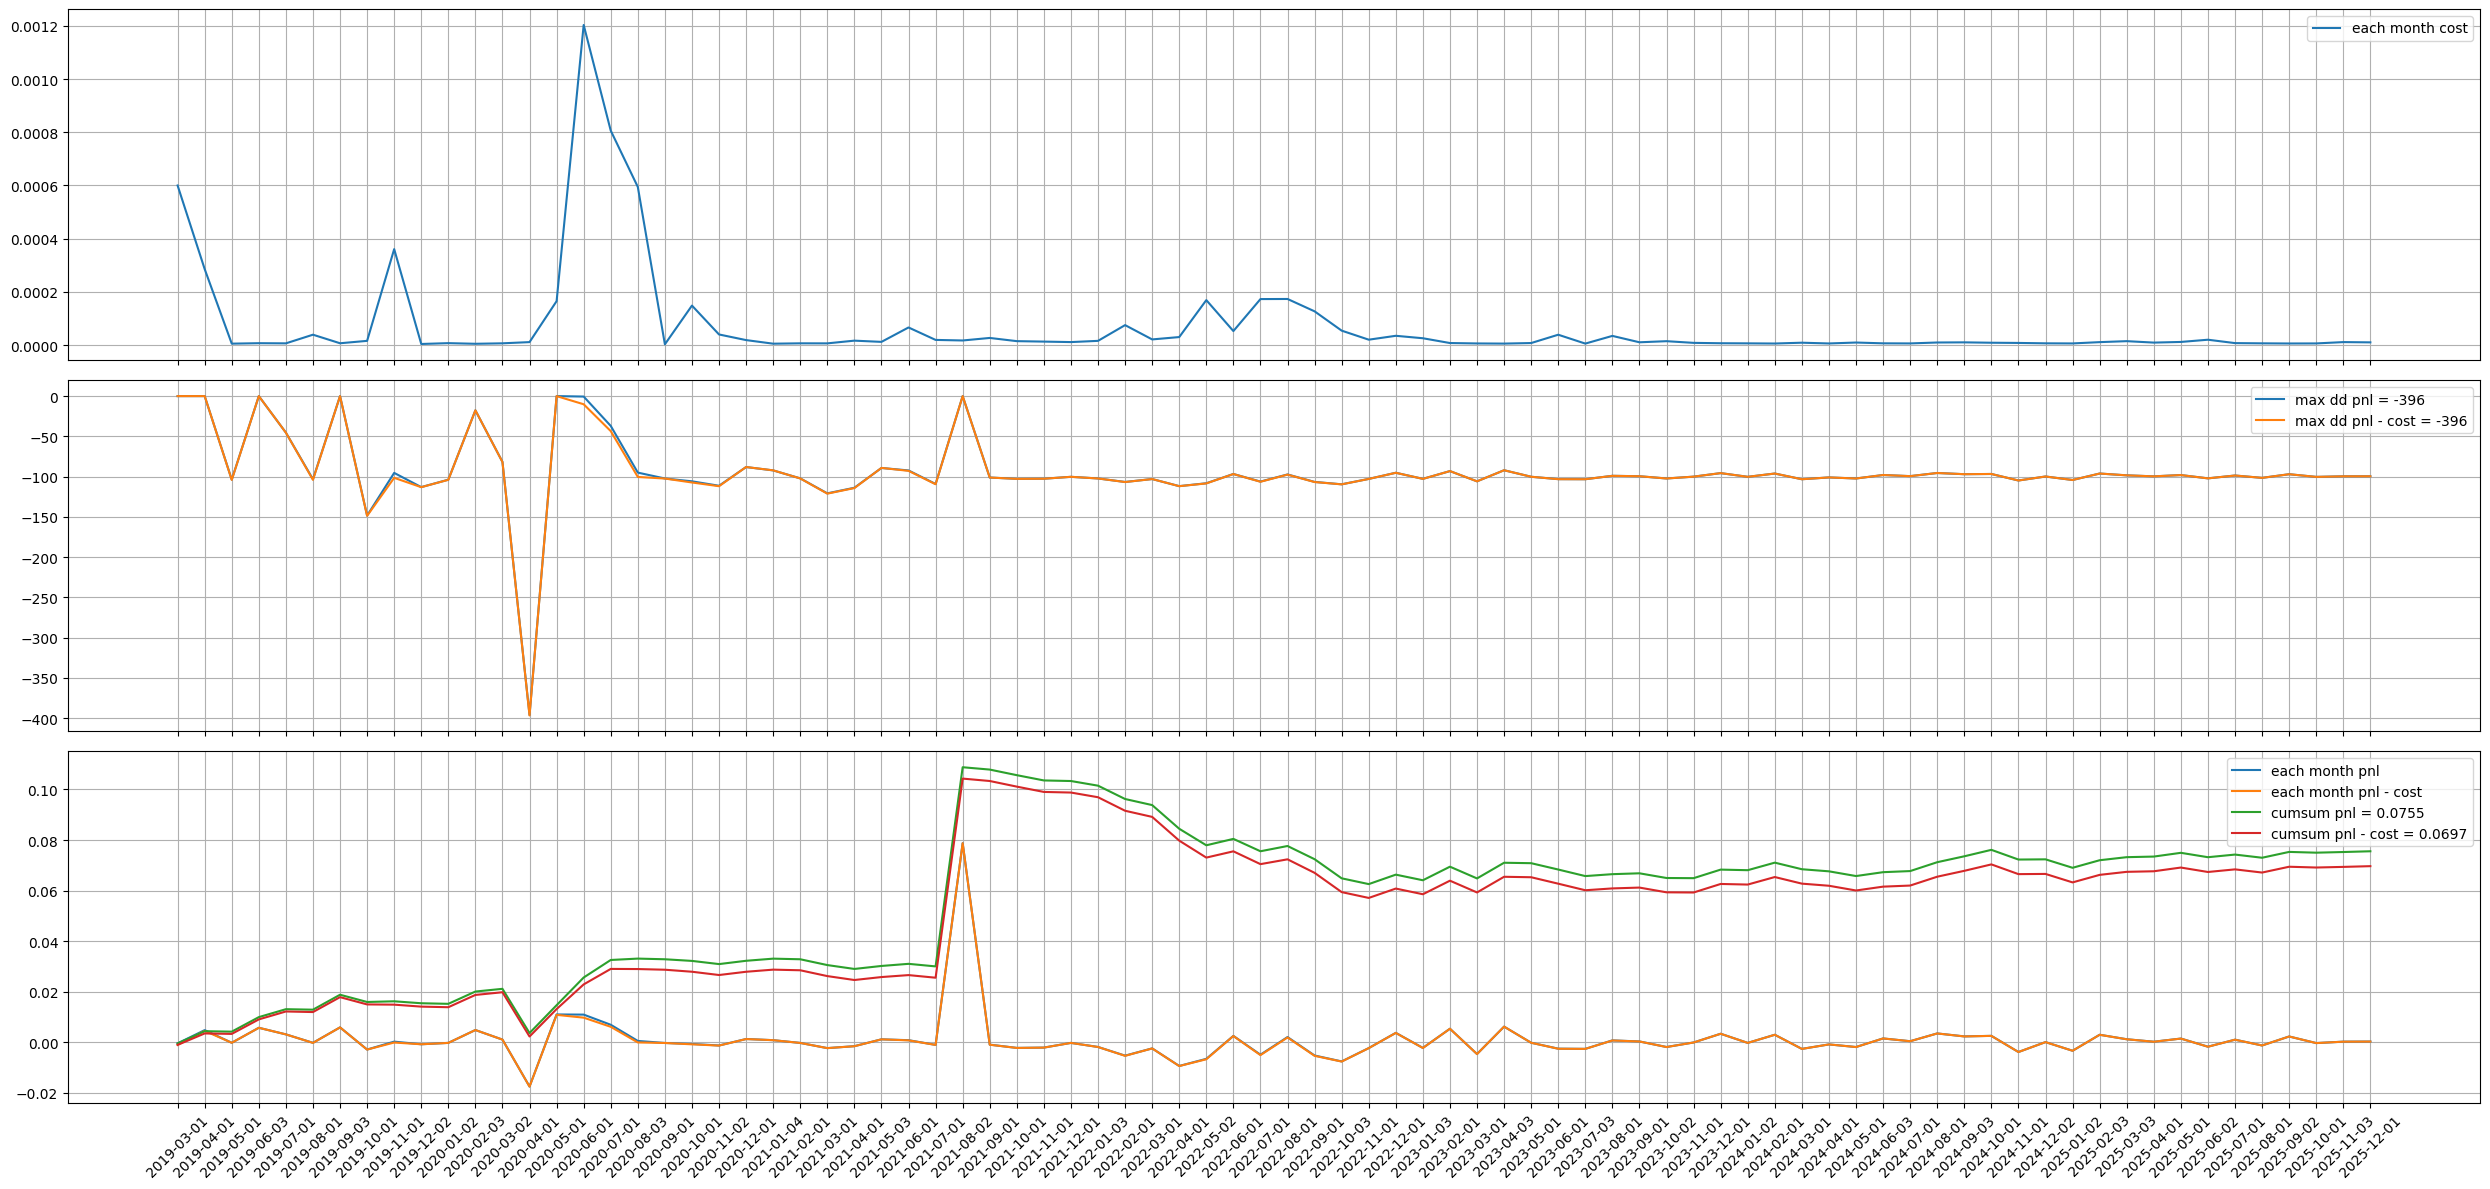

(([0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81],
  [Text(0, 0, '2019-03-01'),
   Text(1, 0, '2019-04-01'),
   Text(2, 0, '2019-05-01'),
   Text(3, 0, '2019-06-03'),
   Text(4, 0, '2019-07-01'),
   Text(5, 0, '2019-08-01'),
   Text(6, 0, '2019-09-03'),
   Text(7, 0, '2019-10-01'),
   Text(8, 0, '2019-11-01'),
   Text(9, 0, '2019-12-02'),
   Text(10, 0, '2020-01-02'),
   Text(11, 0, '2020-02-03'),
   Text(12, 0, '2020-03-02'),
   Text(13, 0, '2020-04-01'),
   Text(14, 0, '2020-05-0

In [76]:
# turnover_penalty = 1.0, no limits in max_iter, CVaR at 99%
pnls = pd.read_csv(path / "pnl.csv")
fig, axes = plt.subplots(3, 1, figsize=(25,12), sharex=True)

axes[0].plot(pnls['Date'], pnls['Cost'], label='each month cost')
# axes[0].plot(pnls['Date'], pnls['Cost'].cumsum(), label='cumsum cost')

running_peak = np.maximum.accumulate(pnls['PnL'])
max_drawdown = (pnls['PnL'] - running_peak) / running_peak * 100
axes[1].plot(pnls['Date'], max_drawdown, label=f'max dd pnl = {int(max_drawdown.min())}')

running_peak = np.maximum.accumulate(pnls['PnL'] - pnls['Cost'])
max_drawdown = (pnls['PnL'] - pnls['Cost'] - running_peak) / running_peak * 100
axes[1].plot(pnls['Date'], max_drawdown, label=f'max dd pnl - cost = {int(max_drawdown.min())}')

axes[2].plot(pnls['Date'], pnls['PnL'], label='each month pnl')
axes[2].plot(pnls['Date'], pnls['PnL']-pnls['Cost'], label='each month pnl - cost')
axes[2].plot(pnls['Date'], pnls['PnL'].cumsum(), label=f"cumsum pnl = {round(pnls['PnL'].cumsum().iloc[-1], 4)}")
axes[2].plot(pnls['Date'], (pnls['PnL']-pnls['Cost']).cumsum(), label=f"cumsum pnl - cost = {round((pnls['PnL']-pnls['Cost']).cumsum().iloc[-1], 4)}")

for i in range(3):
    axes[i].legend(), axes[i].grid()

plt.xticks(rotation=45), plt.tight_layout(), plt.show()


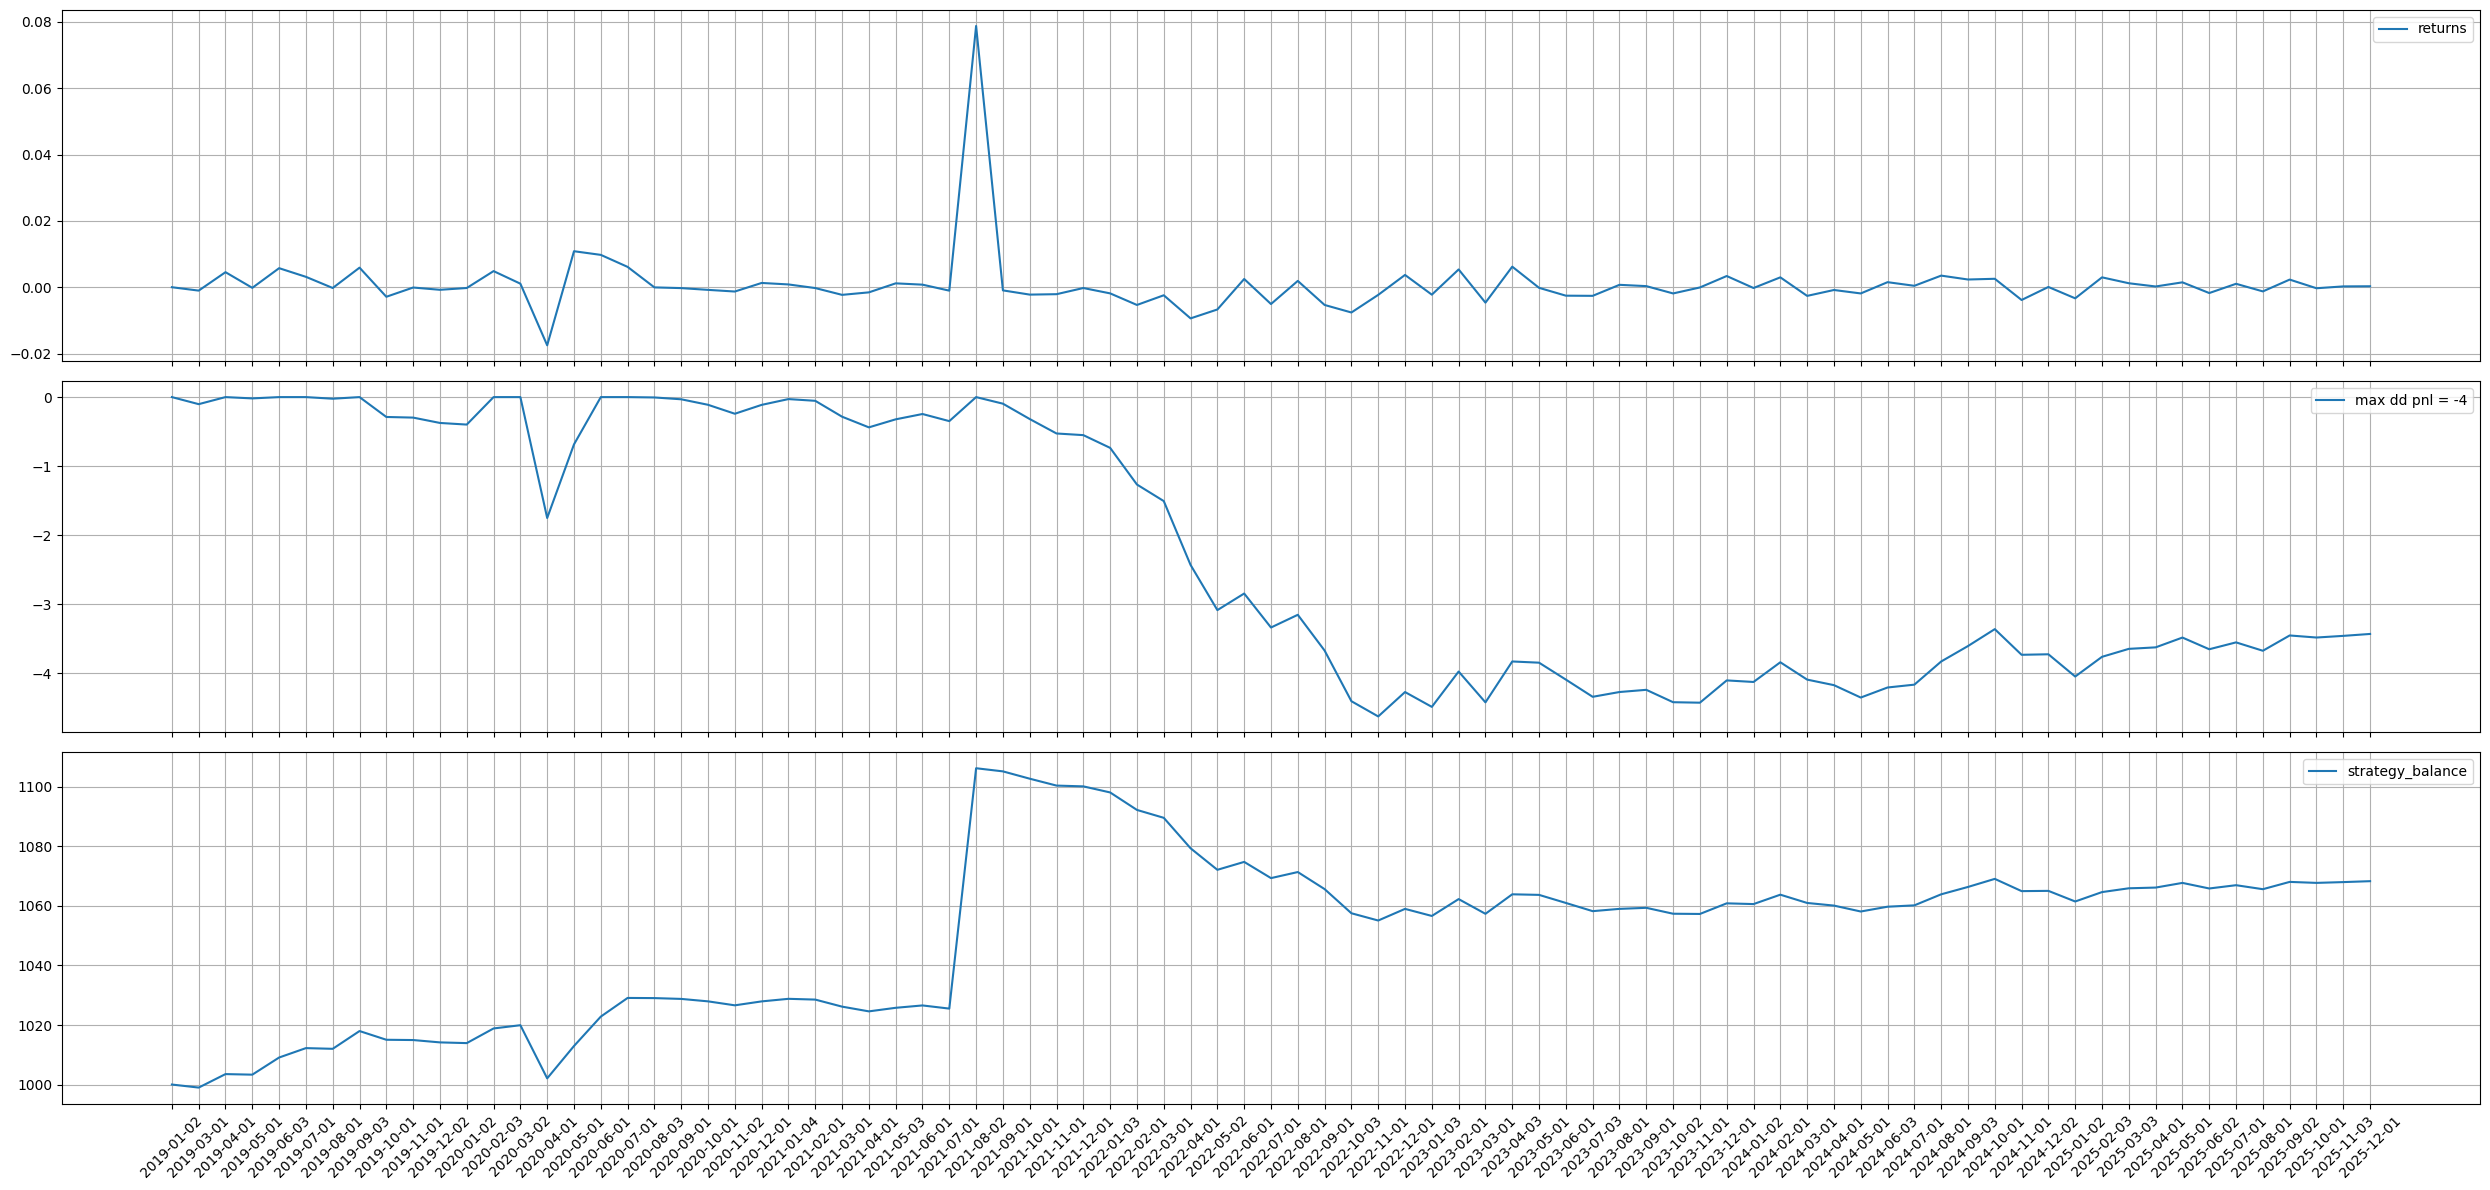

(([0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82],
  [Text(0, 0, '2019-01-02'),
   Text(1, 0, '2019-03-01'),
   Text(2, 0, '2019-04-01'),
   Text(3, 0, '2019-05-01'),
   Text(4, 0, '2019-06-03'),
   Text(5, 0, '2019-07-01'),
   Text(6, 0, '2019-08-01'),
   Text(7, 0, '2019-09-03'),
   Text(8, 0, '2019-10-01'),
   Text(9, 0, '2019-11-01'),
   Text(10, 0, '2019-12-02'),
   Text(11, 0, '2020-01-02'),
   Text(12, 0, '2020-02-03'),
   Text(13, 0, '2020-03-02'),
   Text(14, 0, '20

In [ ]:
# turnover_penalty = 1.0, max_iter=100 + max_iter=1000 + no limits in max_iter (100+ etf)
pnls = pd.read_csv(path / "pnl.csv")
pnls

fig, axes = plt.subplots(3, 1, figsize=(25,12), sharex=True)

axes[0].plot(pnls['Date'], pnls['Returns'], label='returns')

running_peak = np.maximum.accumulate(pnls['Balance'])
max_drawdown = (pnls['Balance'] - running_peak) / running_peak * 100
axes[1].plot(pnls['Date'], max_drawdown, label=f'max dd pnl = {int(max_drawdown.min())}')

axes[2].plot(pnls['Date'], pnls['Balance'], label='strategy_balance')

for i in range(3):
    axes[i].legend(), axes[i].grid()

plt.xticks(rotation=45), plt.tight_layout(), plt.show()


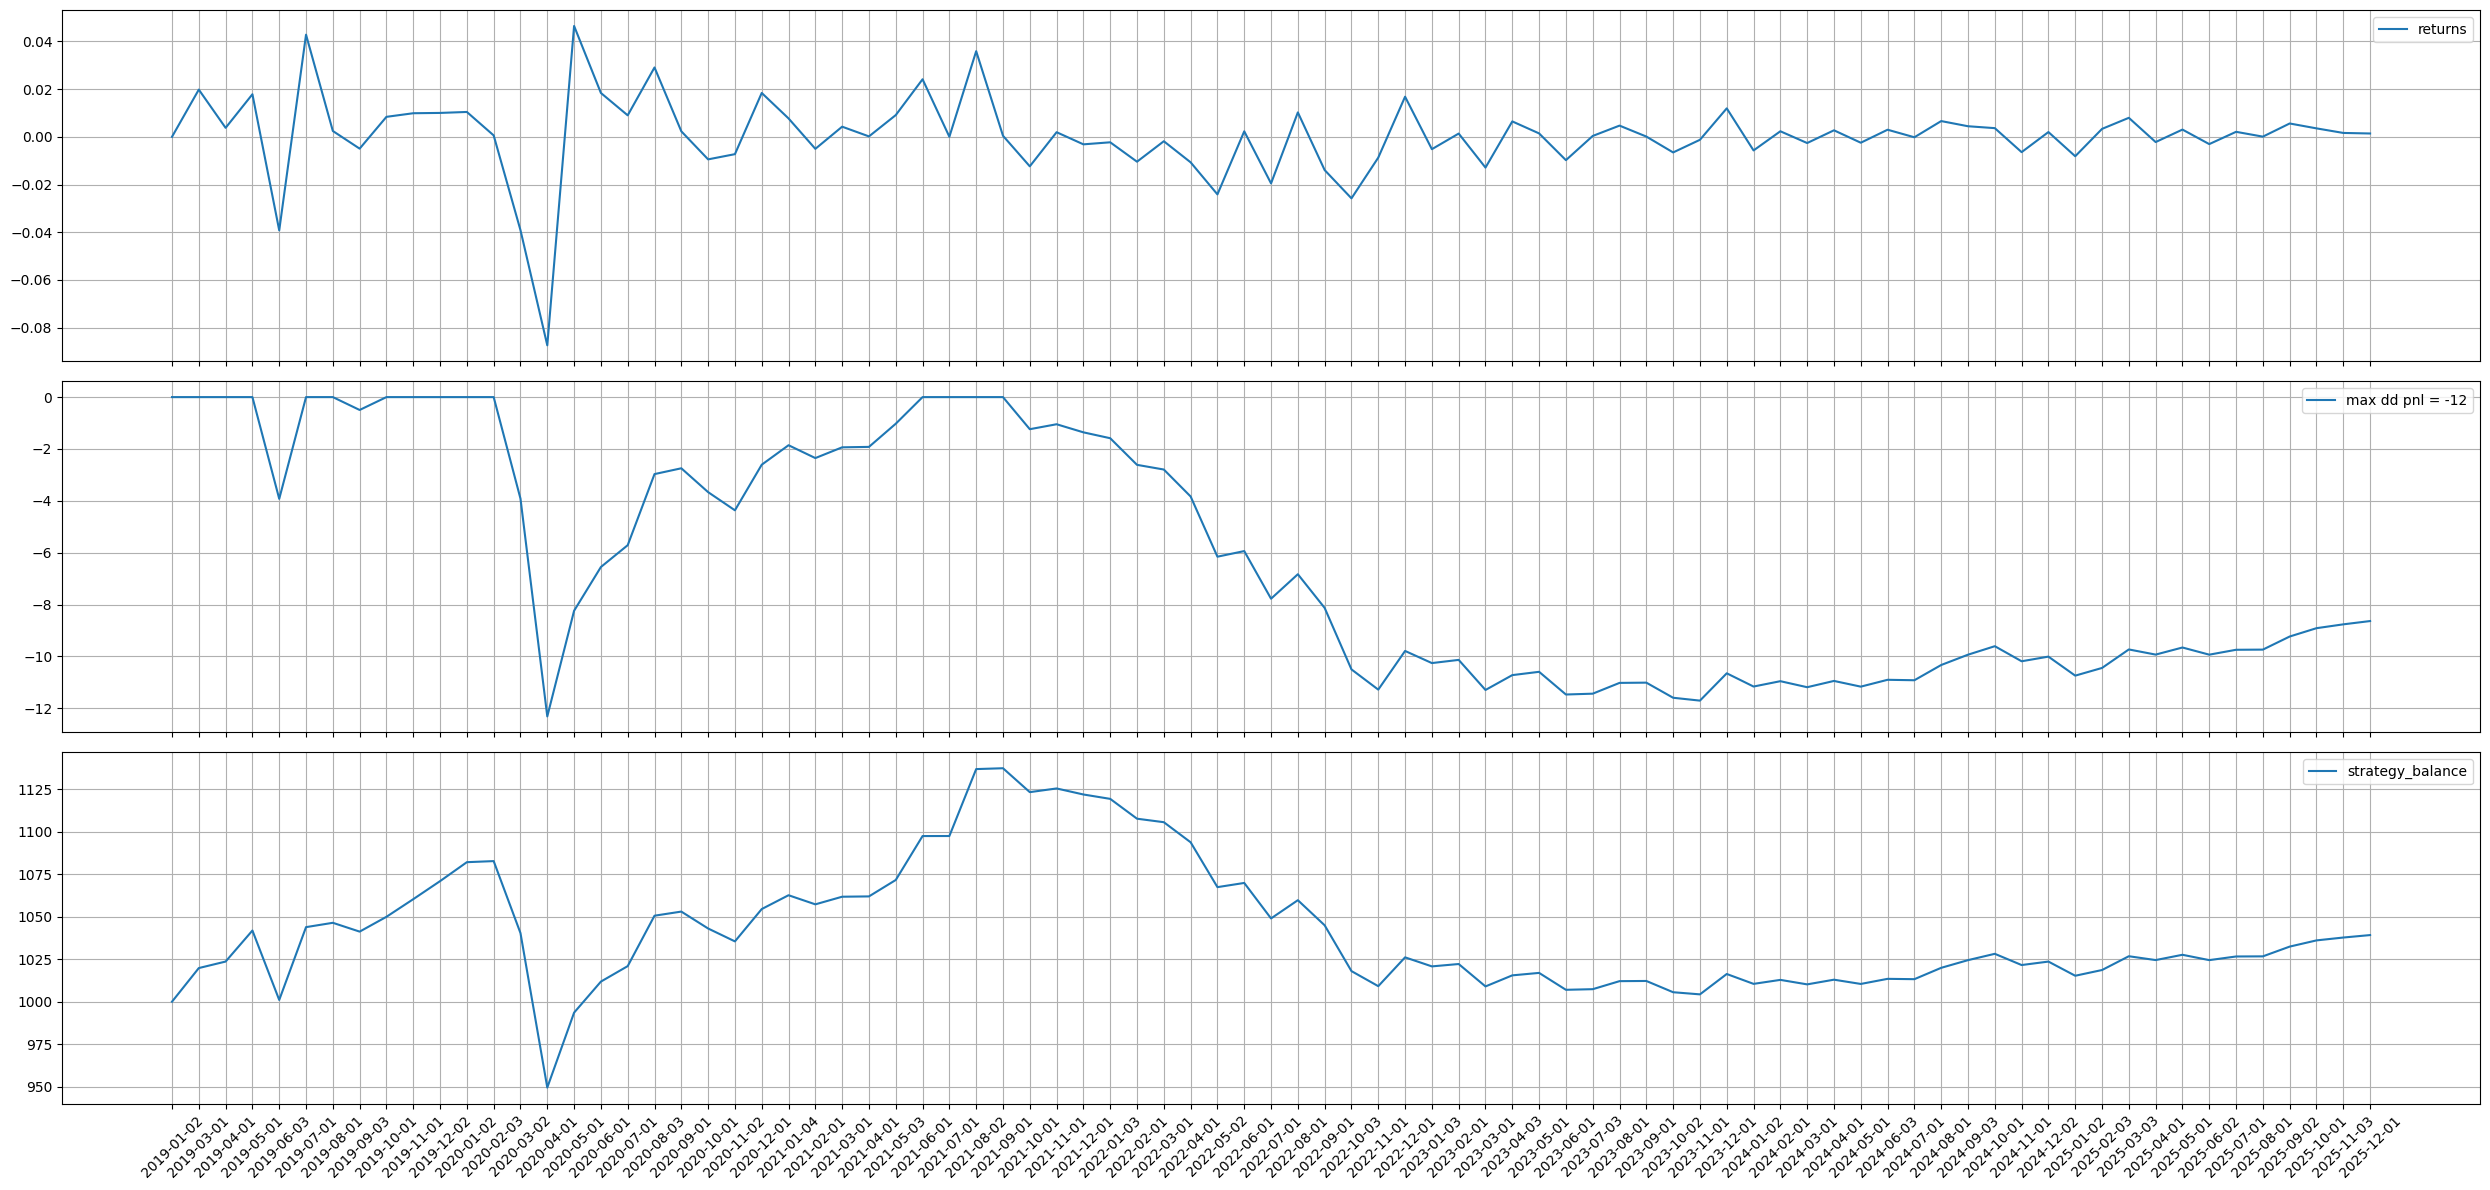

(([0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82],
  [Text(0, 0, '2019-01-02'),
   Text(1, 0, '2019-03-01'),
   Text(2, 0, '2019-04-01'),
   Text(3, 0, '2019-05-01'),
   Text(4, 0, '2019-06-03'),
   Text(5, 0, '2019-07-01'),
   Text(6, 0, '2019-08-01'),
   Text(7, 0, '2019-09-03'),
   Text(8, 0, '2019-10-01'),
   Text(9, 0, '2019-11-01'),
   Text(10, 0, '2019-12-02'),
   Text(11, 0, '2020-01-02'),
   Text(12, 0, '2020-02-03'),
   Text(13, 0, '2020-03-02'),
   Text(14, 0, '20

In [ ]:
# turnover_penalty = 1.0, max_iter=100 + max_iter=1000 + no limits in max_iter (900 etfs)
pnls = pd.read_csv(path / "pnl.csv")
pnls

fig, axes = plt.subplots(3, 1, figsize=(25,12), sharex=True)

axes[0].plot(pnls['Date'], pnls['Returns'], label='returns')

running_peak = np.maximum.accumulate(pnls['Balance'])
max_drawdown = (pnls['Balance'] - running_peak) / running_peak * 100
axes[1].plot(pnls['Date'], max_drawdown, label=f'max dd pnl = {int(max_drawdown.min())}')

axes[2].plot(pnls['Date'], pnls['Balance'], label='strategy_balance')

for i in range(3):
    axes[i].legend(), axes[i].grid()

plt.xticks(rotation=45), plt.tight_layout(), plt.show()


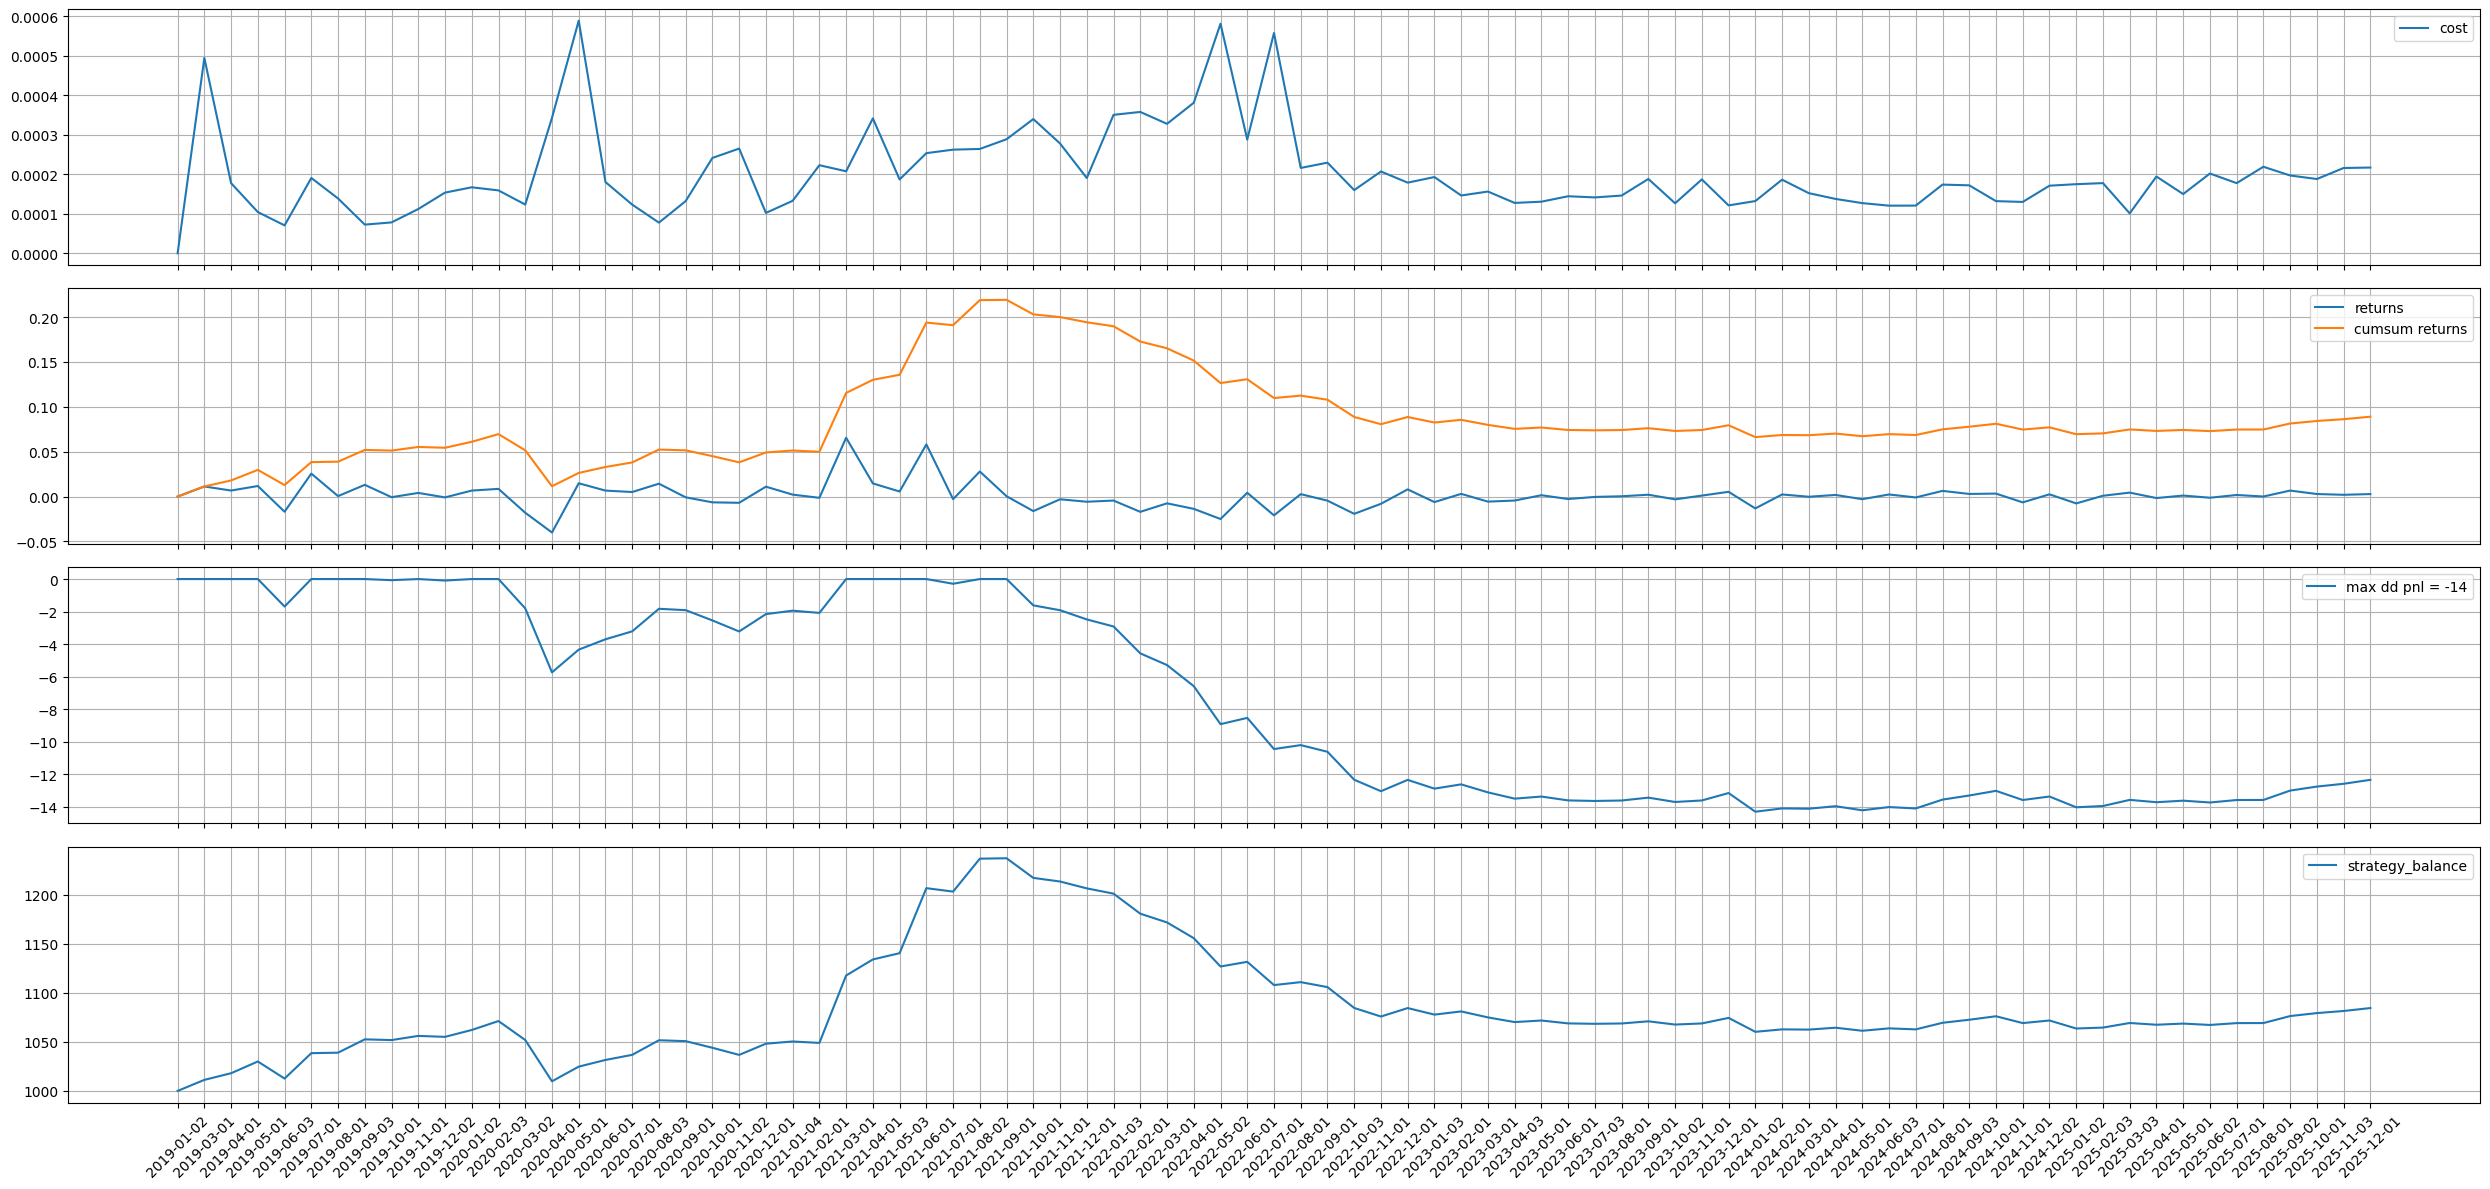

(([0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82],
  [Text(0, 0, '2019-01-02'),
   Text(1, 0, '2019-03-01'),
   Text(2, 0, '2019-04-01'),
   Text(3, 0, '2019-05-01'),
   Text(4, 0, '2019-06-03'),
   Text(5, 0, '2019-07-01'),
   Text(6, 0, '2019-08-01'),
   Text(7, 0, '2019-09-03'),
   Text(8, 0, '2019-10-01'),
   Text(9, 0, '2019-11-01'),
   Text(10, 0, '2019-12-02'),
   Text(11, 0, '2020-01-02'),
   Text(12, 0, '2020-02-03'),
   Text(13, 0, '2020-03-02'),
   Text(14, 0, '20

In [88]:
# turnover_penalty = 1.0, max_iter=100 + max_iter=1000 + no limits in max_iter (900 etfs)
pnls = pd.read_csv(path / "pnl.csv")
pnls

fig, axes = plt.subplots(4, 1, figsize=(25,12), sharex=True)

axes[0].plot(pnls['Date'], pnls['Cost'], label='cost')

axes[1].plot(pnls['Date'], pnls['Returns'], label='returns')
axes[1].plot(pnls['Date'], pnls['Returns'].cumsum(), label='cumsum returns')

running_peak = np.maximum.accumulate(pnls['Balance'])
max_drawdown = (pnls['Balance'] - running_peak) / running_peak * 100
axes[2].plot(pnls['Date'], max_drawdown, label=f'max dd pnl = {int(max_drawdown.min())}')

axes[3].plot(pnls['Date'], pnls['Balance'], label='strategy_balance')

for i in range(4):
    axes[i].legend(), axes[i].grid()

plt.xticks(rotation=45), plt.tight_layout(), plt.show()


In [ ]:
# turnover_penalty = 1.0, max_iter=100 + max_iter=1000 + no limits in max_iter
pnls = pd.read_csv(path / "pnl.csv")
fig, axes = plt.subplots(3, 1, figsize=(25,12), sharex=True)

axes[0].plot(pnls['Date'], pnls['Cost'], label='each month cost')
# axes[0].plot(pnls['Date'], pnls['Cost'].cumsum(), label='cumsum cost')

running_peak = np.maximum.accumulate(pnls['PnL'])
max_drawdown = (pnls['PnL'] - running_peak) / running_peak * 100
axes[1].plot(pnls['Date'], max_drawdown, label=f'max dd pnl = {int(max_drawdown.min())}')

running_peak = np.maximum.accumulate(pnls['PnL'] - pnls['Cost'])
max_drawdown = (pnls['PnL'] - pnls['Cost'] - running_peak) / running_peak * 100
axes[1].plot(pnls['Date'], max_drawdown, label=f'max dd pnl - cost = {int(max_drawdown.min())}')

axes[2].plot(pnls['Date'], pnls['PnL'], label='each month pnl')
axes[2].plot(pnls['Date'], pnls['PnL']-pnls['Cost'], label='each month pnl - cost')
axes[2].plot(pnls['Date'], pnls['PnL'].cumsum(), label=f"cumsum pnl = {round(pnls['PnL'].cumsum().iloc[-1], 4)}")
axes[2].plot(pnls['Date'], (pnls['PnL']-pnls['Cost']).cumsum(), label=f"cumsum pnl - cost = {round((pnls['PnL']-pnls['Cost']).cumsum().iloc[-1], 4)}")

for i in range(3):
    axes[i].legend(), axes[i].grid()

plt.xticks(rotation=45), plt.tight_layout(), plt.show()


In [81]:
returns_reward = pnls['PnL']-pnls['Cost']
np.mean(returns_reward) / np.std(returns_reward)


np.float64(0.0894959755399441)

In [75]:
pnls = pd.read_csv(path / "pnl.csv")

fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=('Costs', 'Maximum Drawdown', 'PnL'),
    row_heights=[0.33, 0.33, 0.33]
)

fig.add_trace(go.Scatter(x=pnls['Date'], y=pnls['Cost'], mode='lines', name='each month cost'), row=1, col=1)

running_peak_pnl = np.maximum.accumulate(pnls['PnL'])
max_drawdown_pnl = (pnls['PnL'] - running_peak_pnl) / running_peak_pnl * 100

running_peak_net = np.maximum.accumulate(pnls['PnL'] - pnls['Cost'])
max_drawdown_net = (pnls['PnL'] - pnls['Cost'] - running_peak_net) / running_peak_net * 100

fig.add_trace(go.Scatter(x=pnls['Date'], y=max_drawdown_pnl, mode='lines', name=f'max dd pnl = {int(max_drawdown_pnl.min())}%'), row=2, col=1)
fig.add_trace(go.Scatter(x=pnls['Date'], y=max_drawdown_net, mode='lines', name=f'max dd pnl - cost = {int(max_drawdown_net.min())}%'),row=2, col=1)

fig.add_trace(go.Scatter(x=pnls['Date'], y=pnls['PnL'], mode='lines', name='each month pnl'), row=3, col=1)
fig.add_trace(go.Scatter(x=pnls['Date'], y=pnls['PnL'] - pnls['Cost'], mode='lines', name='each month pnl - cost'), row=3, col=1)

cumsum_pnl = pnls['PnL'].cumsum()
fig.add_trace(go.Scatter(x=pnls['Date'], y=cumsum_pnl, mode='lines', name=f"cumsum pnl = {round(cumsum_pnl.iloc[-1], 4)}"), row=3, col=1)

cumsum_net = (pnls['PnL'] - pnls['Cost']).cumsum()
fig.add_trace(go.Scatter(x=pnls['Date'], y=cumsum_net, mode='lines', name=f"cumsum pnl - cost = {round(cumsum_net.iloc[-1], 4)}"), row=3, col=1)


fig.update_layout(
    height=1200,
    width=1800,
    title_text="Portfolio Analysis",
    showlegend=True,
    hovermode='x unified'
)

fig.update_xaxes(title_text="Date", row=3, col=1, tickangle=45)
fig.update_yaxes(title_text="Cost", row=1, col=1)
fig.update_yaxes(title_text="Drawdown (%)", row=2, col=1)
fig.update_yaxes(title_text="PnL", row=3, col=1)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')

fig.show()


In [ ]:
first_business_days.index[first_business_days == pd.to_datetime('2021-10-01')]
# first_business_days.iloc[60]
# pnls


Index([69], dtype='int64')

In [24]:
start_date = first_business_days.iloc[0] + timedelta(days=365*3)
start_date


Timestamp('2019-01-31 00:00:00')

In [31]:
initial_date = first_business_days[first_business_days <= start_date].iloc[-1]
index = first_business_days.index[first_business_days == initial_date].to_numpy()[0]
index, initial_date


(np.int64(36), Timestamp('2019-01-02 00:00:00'))

In [32]:
first_business_days.iloc[index:-1]


37    2019-02-01
38    2019-03-01
39    2019-04-01
40    2019-05-01
41    2019-06-03
         ...    
114   2025-07-01
115   2025-08-01
116   2025-09-02
117   2025-10-01
118   2025-11-03
Name: Values, Length: 82, dtype: datetime64[ns]